# Wind Event in Junes from 2018 to 2026

The notebooks visualizes the wind speed during 2018-2026 at Juan de Fuca.

## Wind Event 2026

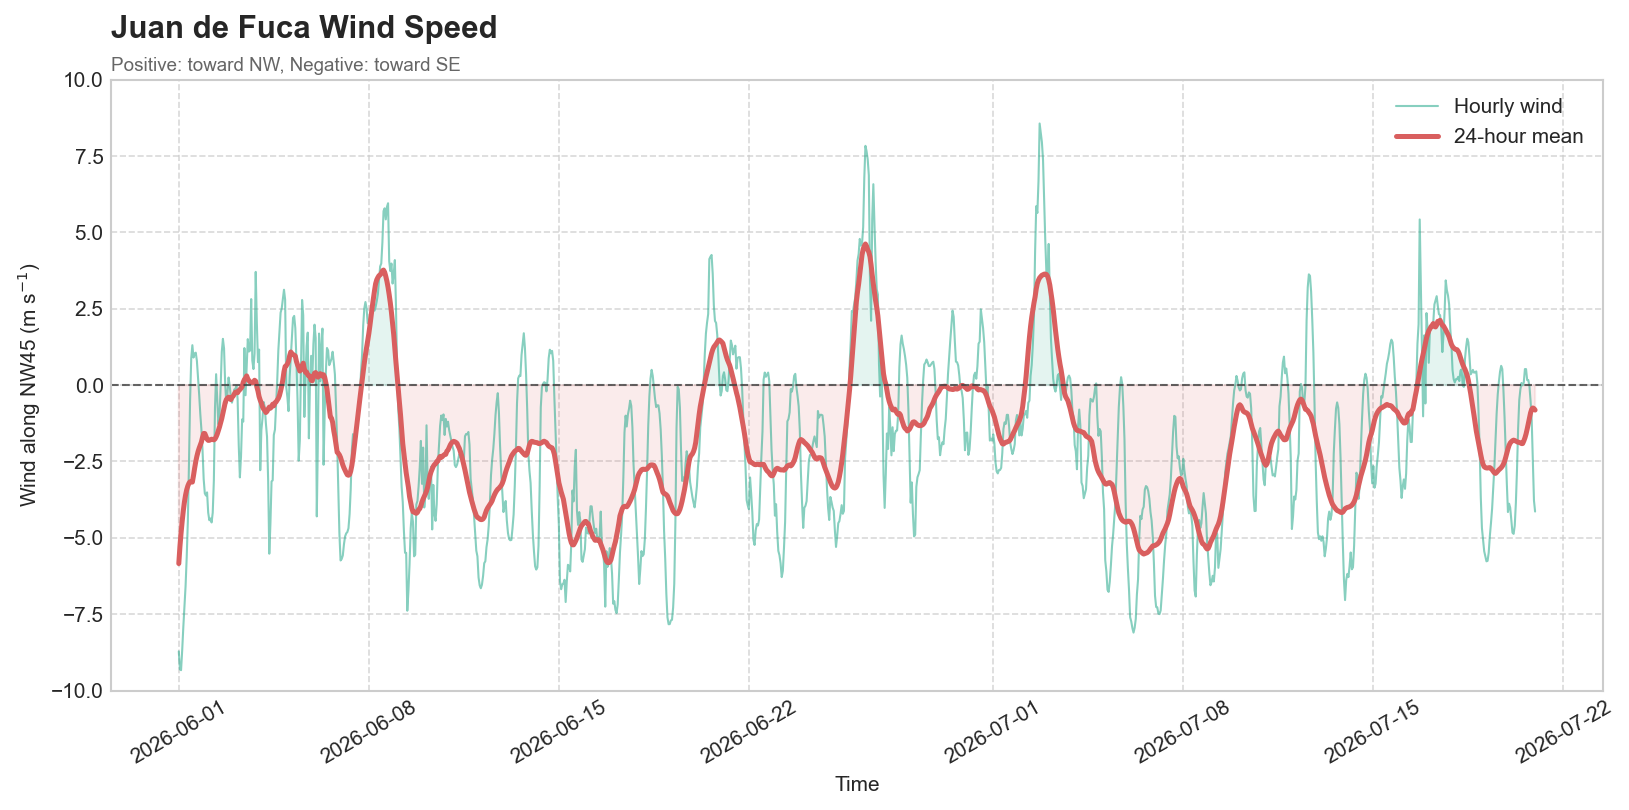

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# path and load

path_2026='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_atmo_events/hrdps_wind_202606.csv'

wind_2026=pd.read_csv(path_2026)
wind_2026["time"] = pd.to_datetime(wind_2026["time"])

time=wind_2026['time']
wind_NW45=wind_2026['wind_NW45']

# smoothing

wind_NW45_smoothed=wind_NW45.rolling(24,center=True,min_periods=6).mean()

# visualize

fig, ax = plt.subplots(
    figsize=(11, 5.5),
    dpi=150,
)

# hourly wind speed
ax.plot(
    time,
    wind_NW45,
    color="#24a98b",
    lw=1.0,
    alpha=0.55,
    label="Hourly wind",
)

# smoothed
ax.plot(
    time,
    wind_NW45_smoothed,
    color="#d95f5f",
    lw=2.4,
    label="24-hour mean",
)

# 0 reference line
ax.axhline(
    y=0,
    color="0.25",
    lw=1.0,
    linestyle="--",
    alpha=0.8,
)

# color fill
ax.fill_between(
    time,
    0,
    wind_NW45_smoothed,
    where=wind_NW45_smoothed >= 0,
    interpolate=True,
    color="#24a98b",
    alpha=0.12,
)

ax.fill_between(
    time,
    0,
    wind_NW45_smoothed,
    where=wind_NW45_smoothed < 0,
    interpolate=True,
    color="#d95f5f",
    alpha=0.12,
)

ax.set_title(
    "Juan de Fuca Wind Speed",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

ax.text(
    0,
    1.015,
    "Positive: toward NW, Negative: toward SE",
    transform=ax.transAxes,
    color="0.4",
    fontsize=9,
)

ax.set_xlabel("Time")
ax.set_ylabel("Wind along NW45 (m s$^{-1}$)")

ax.set_ylim(-10,10)

ax.tick_params(
    axis="x",
    rotation=30,
)

ax.grid(
    True,
    alpha=0.75,
    linestyle="--",
)

ax.legend(
    loc="best",
    frameon=False,
)

fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

fig.tight_layout()
plt.show()

## Wind in Junes during 2018-2026

In [5]:
# Junes Visualization

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# Paths and loading

path_2018_2022='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_atmo_events/Data_hrdps_June_JdF_2018_2022.csv'
path_2023_2026='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_atmo_events/Data_hrdps_June_JdF_2023_2026.csv'

wind_2018_2022=pd.read_csv(path_2018_2022)
wind_2023_2026=pd.read_csv(path_2023_2026)

wind_2018_2026=pd.concat([wind_2018_2022,wind_2023_2026])

wind_2018_2026['time']=pd.to_datetime(wind_2018_2026['time'])

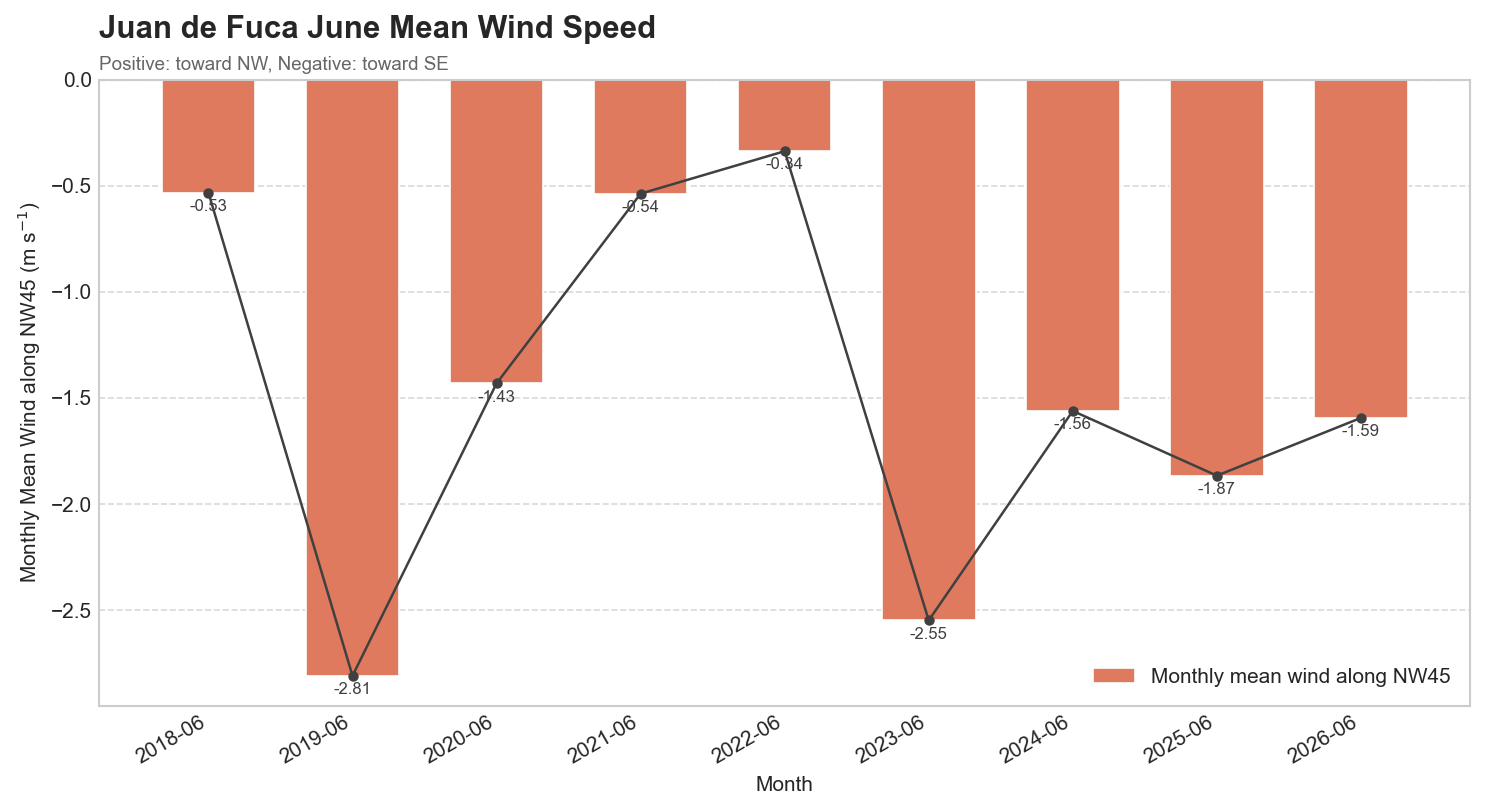

In [ ]:
# Monthly mean visualization

wind_2018_2026["month"] = wind_2018_2026["time"].dt.to_period("M")

monthly_mean = (
    wind_2018_2026.groupby("month", as_index=False)
    .agg(
        u_wind_mean=("u_wind", "mean"),
        v_wind_mean=("v_wind", "mean"),
        wind_speed_mean=("wind_speed", "mean"),
        wind_NW45_mean=("wind_NW45", "mean"),
        wind_SE45_mean=("wind_SE45", "mean"),
        record_count=("time", "size"),
    )
    .sort_values("month")
    .reset_index(drop=True)
)

# month to time
monthly_mean["time"] = monthly_mean["month"].dt.to_timestamp()

# YYYY-MM label
monthly_mean["month_label"] = monthly_mean["month"].astype(str)

# visualization

fig, ax = plt.subplots(
    figsize=(10, 5.5),
    dpi=150,
)

x = np.arange(len(monthly_mean))
y = monthly_mean["wind_NW45_mean"]



# Positive: towards NW
# Negative: towards SE
bar_colors = np.where(
    y >= 0,
    "#24a98b",
    "#e07a5f",
)

bars = ax.bar(
    x,
    y,
    width=0.65,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
    label="Monthly mean wind along NW45",
)


# dots and line
ax.plot(
    x,
    y,
    color="0.25",
    lw=1.2,
    marker="o",
    markersize=4,
    zorder=3,
)


# 0 reference line
ax.axhline(
    0,
    color="0.25",
    lw=1,
    linestyle="--",
    alpha=0.8,
)


# speed 
for bar, value in zip(bars, y):

    if value >= 0:
        vertical_alignment = "bottom"
        y_offset = 3
    else:
        vertical_alignment = "top"
        y_offset = -3

    ax.annotate(
        f"{value:.2f}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            value,
        ),
        xytext=(0, y_offset),
        textcoords="offset points",
        ha="center",
        va=vertical_alignment,
        fontsize=8,
        color="0.25",
    )


ax.set_xticks(x)
ax.set_xticklabels(
    monthly_mean["month_label"],
    rotation=30,
    ha="right",
)

ax.set_title(
    "Juan de Fuca June Mean Wind Speed",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

ax.text(
    0,
    1.015,
    "Positive: toward NW, Negative: toward SE",
    transform=ax.transAxes,
    color="0.4",
    fontsize=9,
)

ax.set_xlabel("Month")
ax.set_ylabel("Monthly Mean Wind along NW45 (m s$^{-1}$)")

ax.grid(
    True,
    axis="y",
    alpha=0.75,
    linestyle="--",
)

ax.grid(
    False,
    axis="x",
)

ax.legend(
    loc="best",
    frameon=False,
)

# 如果希望固定纵坐标范围，可以取消下面这一行的注释
# ax.set_ylim(-10, 10)

fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

fig.tight_layout()


plt.show()

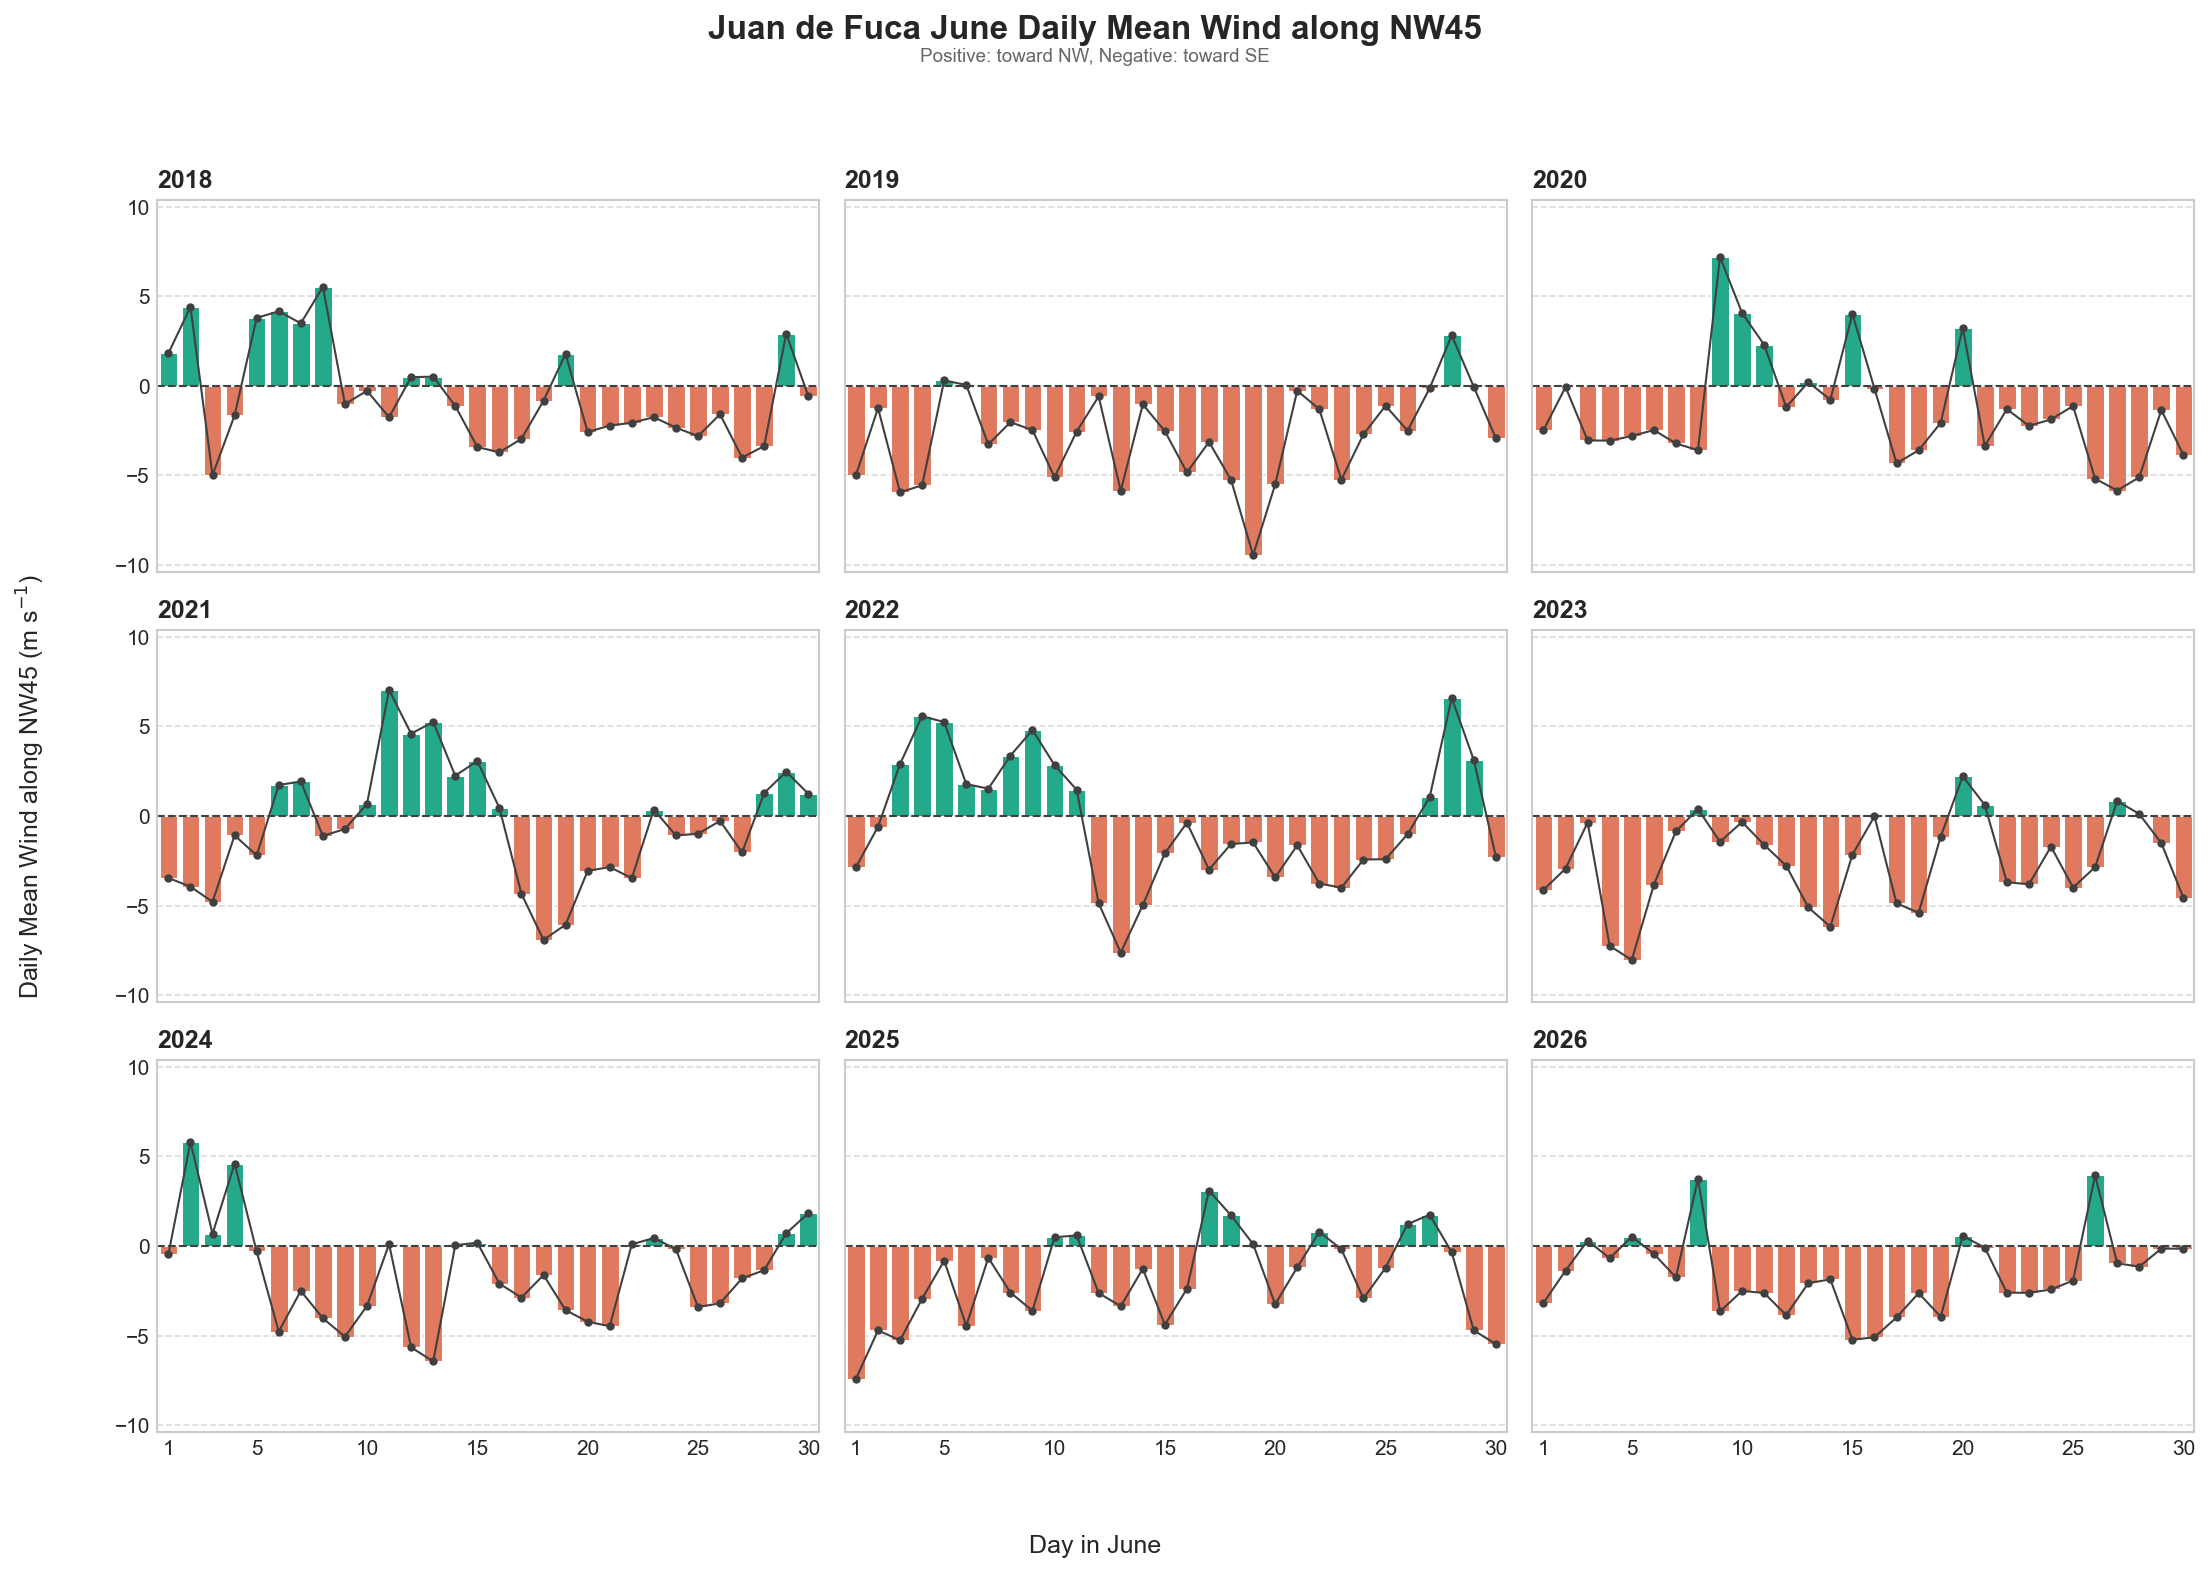

In [9]:
import math

# visualization of daily means

wind_2018_2026["date"] = wind_2018_2026["time"].dt.floor("D")

daily_mean = (
    wind_2018_2026.groupby("date", as_index=False)
    .agg(
        u_wind_mean=("u_wind", "mean"),
        v_wind_mean=("v_wind", "mean"),
        wind_speed_mean=("wind_speed", "mean"),
        wind_NW45_mean=("wind_NW45", "mean"),
        wind_SE45_mean=("wind_SE45", "mean"),
    )
    .sort_values("date")
    .reset_index(drop=True)
)

daily_mean["year"] = daily_mean["date"].dt.year
daily_mean["day"] = daily_mean["date"].dt.day

# visualize

years = sorted(
    daily_mean["year"].unique()
)

ncols = 3
nrows = math.ceil(len(years) / ncols)


fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 3.5 * nrows),
    dpi=150,
    sharex=True,
    sharey=True,
)

axes = np.atleast_1d(axes).ravel()


# 所有子图使用相同的纵坐标范围
max_abs_value = daily_mean["wind_NW45_mean"].abs().max()
y_limit = max(max_abs_value * 1.1, 1)


for ax, year in zip(axes, years):

    year_data = (
        daily_mean.loc[
            daily_mean["year"] == year
        ]
        .sort_values("date")
    )

    x = year_data["day"]
    y = year_data["wind_NW45_mean"]


    # 正值：吹向 NW
    # 负值：吹向 SE
    bar_colors = np.where(
        y >= 0,
        "#24a98b",
        "#e07a5f",
    )


    ax.bar(
        x,
        y,
        width=0.8,
        color=bar_colors,
        edgecolor="white",
        linewidth=0.5,
    )


    ax.plot(
        x,
        y,
        color="0.25",
        linewidth=1,
        marker="o",
        markersize=3,
    )


    ax.axhline(
        0,
        color="0.25",
        linewidth=1,
        linestyle="--",
    )


    ax.set_title(
        str(year),
        loc="left",
        fontsize=12,
        fontweight="bold",
    )


    ax.set_xlim(0.5, 30.5)
    ax.set_ylim(-y_limit, y_limit)

    ax.set_xticks(
        [1, 5, 10, 15, 20, 25, 30]
    )


    ax.grid(
        True,
        axis="y",
        linestyle="--",
        alpha=0.7,
    )

    ax.grid(
        False,
        axis="x",
    )


# 删除多余的空子图
for ax in axes[len(years):]:
    ax.remove()


fig.suptitle(
    "Juan de Fuca June Daily Mean Wind along NW45",
    fontsize=16,
    fontweight="bold",
    y=0.99,
)

fig.text(
    0.5,
    0.96,
    "Positive: toward NW, Negative: toward SE",
    ha="center",
    fontsize=9,
    color="0.4",
)

fig.supxlabel("Day in June")

fig.supylabel(
    "Daily Mean Wind along NW45 (m s$^{-1}$)"
)

fig.tight_layout(
    rect=[0.03, 0.03, 1, 0.94]
)

plt.show()

Strong wind from Northwest was observed in Jun and early July, but no evidence indicates that the wind in 2026 is significantly stronger or more persistent than that in other years.

The low-oxygen was probably caused by wind-driven coastal upwelling, but wind alone cannot explain even lower oxygen compared to other years.